# 01 — EDA & Dataset Overview

Exploratory data analysis for the thesis project.  
- Prices, returns, volatility
- Rolling correlations
- Distribution tests
- Stationarity (ADF)


In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## How to read this notebook
This notebook documents the statistical properties of the dataset used in the thesis. Focus on volatility clustering, non-normality, and time variation in BTC-to-traditional-asset correlations, because these motivate the forecasting task.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os
# Add project root to path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from thesis_app.pipeline import load_config, build_paths, fetch_prices, compute_returns, fisher_z, rolling_corr

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (13, 5)

cfg = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(cfg['base_dir'])
print('Config loaded. base_dir =', cfg['base_dir'])

Config loaded. base_dir = D:/clode9


In [3]:
# ─── Load data ────────────────────────────────────────────────────
tickers = cfg['assets']['crypto'] + cfg['assets']['traditional']
prices = fetch_prices(paths, tickers, cfg['start_date'], cfg.get('end_date'))
rets   = compute_returns(paths, prices)

print(f'Prices shape: {prices.shape}   {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Returns shape: {rets.shape}')
rets.tail(3)

Re-downloading: cached date range does not cover config dates.


[                       0%                       ]

[**************        29%                       ]  2 of 7 completed

[********************* 43%                       ]  3 of 7 completed

[**********************57%**                     ]  4 of 7 completed

[**********************71%*********              ]  5 of 7 completed

[**********************86%****************       ]  6 of 7 completed

[*********************100%***********************]  7 of 7 completed

Saved prices: D:/clode9\data\raw\prices.csv shape=(3018, 7)
Prices shape: (3018, 7)   2017-11-09 → 2026-04-11
Returns shape: (3017, 7)


,BTC-USD,ETH-USD,GLD,SLV,UUP,^GSPC,^IXIC
Date,,,,,,,
2026-04-09,0.009020,-0.000544,0.007748,0.013544,-0.001818,0.006151,0.008246
2026-04-10,0.016736,0.025261,-0.001783,0.010039,-0.001457,-0.001139,0.003520
2026-04-11,-0.003467,-0.005441,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
# ─── Descriptive stats ────────────────────────────────────────────
desc = rets.describe().T
desc['skew'] = rets.skew()
desc['kurt'] = rets.kurtosis()
desc.style.format('{:.4f}').background_gradient(axis=0, subset=['std','skew','kurt'])

,count,mean,std,min,25%,50%,75%,max,skew,kurt
BTC-USD,3017.0000,0.0008,0.0354,-0.4647,-0.0138,0.0007,0.0154,0.2251,-0.7279,13.3807
ETH-USD,3017.0000,0.0006,0.0458,-0.5507,-0.0191,0.0005,0.0214,0.2949,-0.7393,10.7800
GLD,3017.0000,0.0004,0.0087,-0.1084,-0.0019,0.0000,0.0035,0.0616,-0.8942,14.0085
SLV,3017.0000,0.0005,0.0177,-0.3360,-0.0038,0.0000,0.0055,0.0875,-2.7972,51.8914
UUP,3017.0000,0.0001,0.0037,-0.0326,-0.0012,0.0000,0.0015,0.0371,-0.0264,8.5634
^GSPC,3017.0000,0.0003,0.0102,-0.1277,-0.0017,0.0000,0.0037,0.0909,-0.7321,22.5912
^IXIC,3017.0000,0.0004,0.0124,-0.1315,-0.0021,0.0000,0.0051,0.1148,-0.4560,12.6724


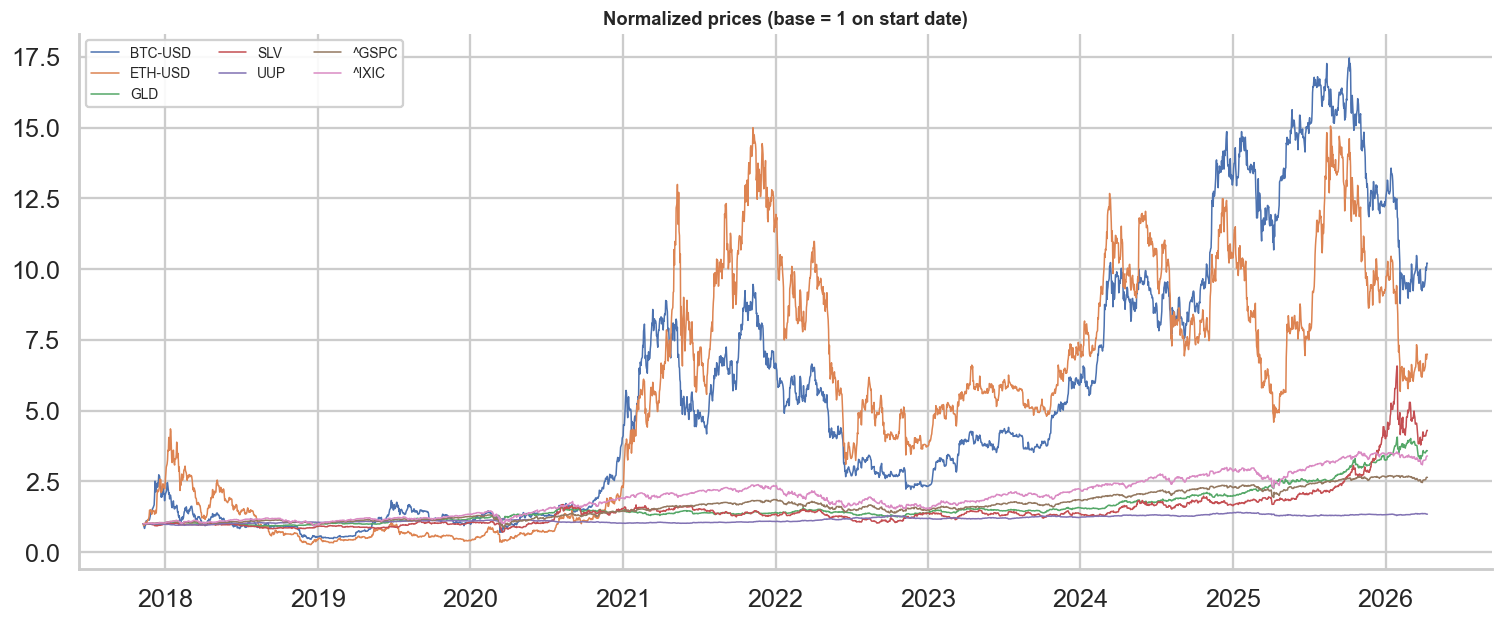

In [5]:
# ─── Normalized price series ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for c in prices.columns:
    ax.plot(prices.index, prices[c] / prices[c].iloc[0], label=c, lw=1)
ax.set_title('Normalized prices (base = 1 on start date)', fontsize=12)
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_normalized_prices.png'), dpi=130)
plt.show()

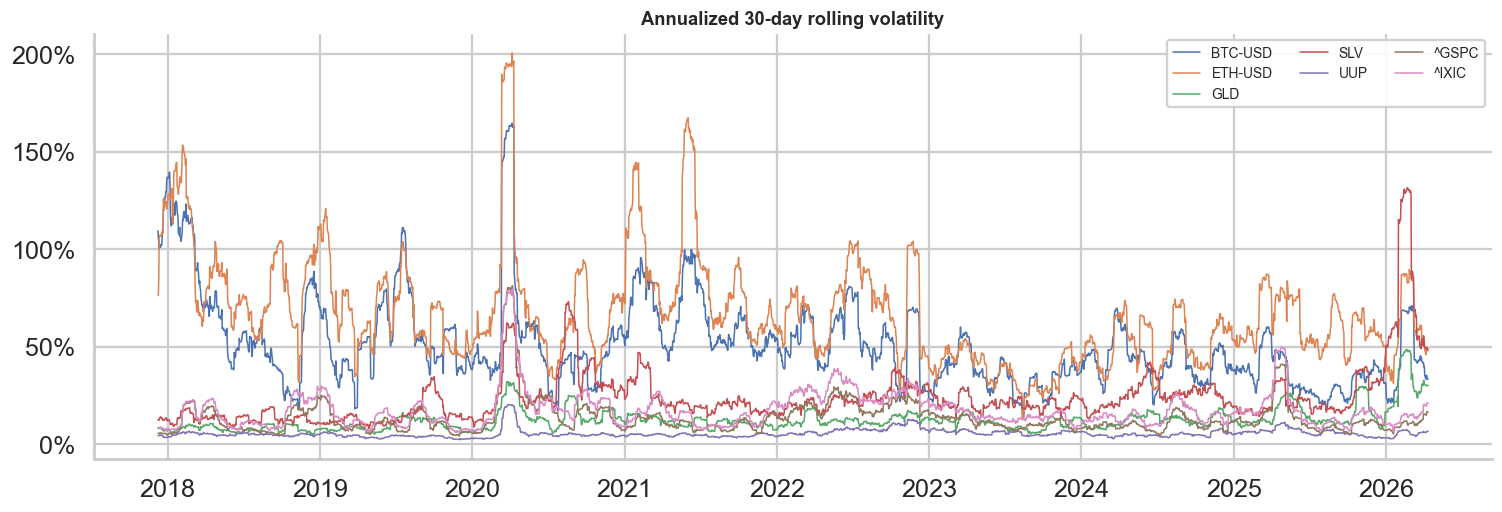

In [6]:
# ─── Rolling volatility ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for c in rets.columns:
    rv = rets[c].rolling(30).std() * np.sqrt(252)  # annualized
    ax.plot(rv.index, rv, label=c, lw=1)
ax.set_title('Annualized 30-day rolling volatility', fontsize=12)
ax.legend(ncol=3, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_rolling_vol.png'), dpi=130)
plt.show()

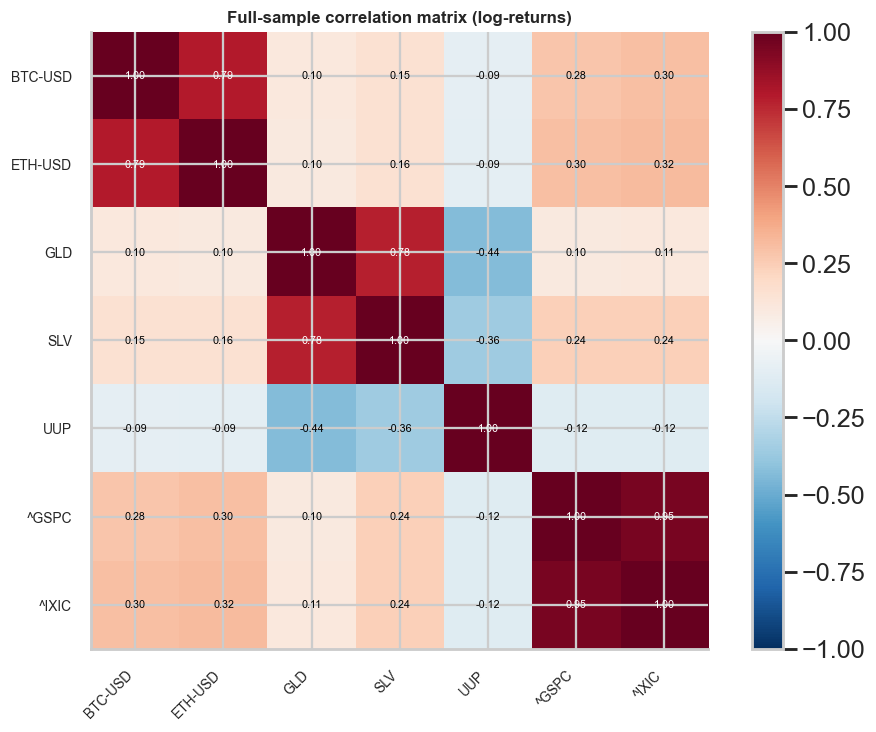

         BTC-USD  ETH-USD    GLD    SLV    UUP  ^GSPC  ^IXIC
BTC-USD    1.000    0.793  0.102  0.150 -0.091  0.279  0.299
ETH-USD    0.793    1.000  0.101  0.156 -0.095  0.298  0.316
GLD        0.102    0.101  1.000  0.778 -0.437  0.100  0.107
SLV        0.150    0.156  0.778  1.000 -0.357  0.235  0.238
UUP       -0.091   -0.095 -0.437 -0.357  1.000 -0.124 -0.125
^GSPC      0.279    0.298  0.100  0.235 -0.124  1.000  0.951
^IXIC      0.299    0.316  0.107  0.238 -0.125  0.951  1.000


In [7]:
# ─── Full-sample correlation heatmap ──────────────────────────────
corr = rets.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Full-sample correlation matrix (log-returns)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_corr_heatmap.png'), dpi=130)
plt.show()
print(corr.round(3))

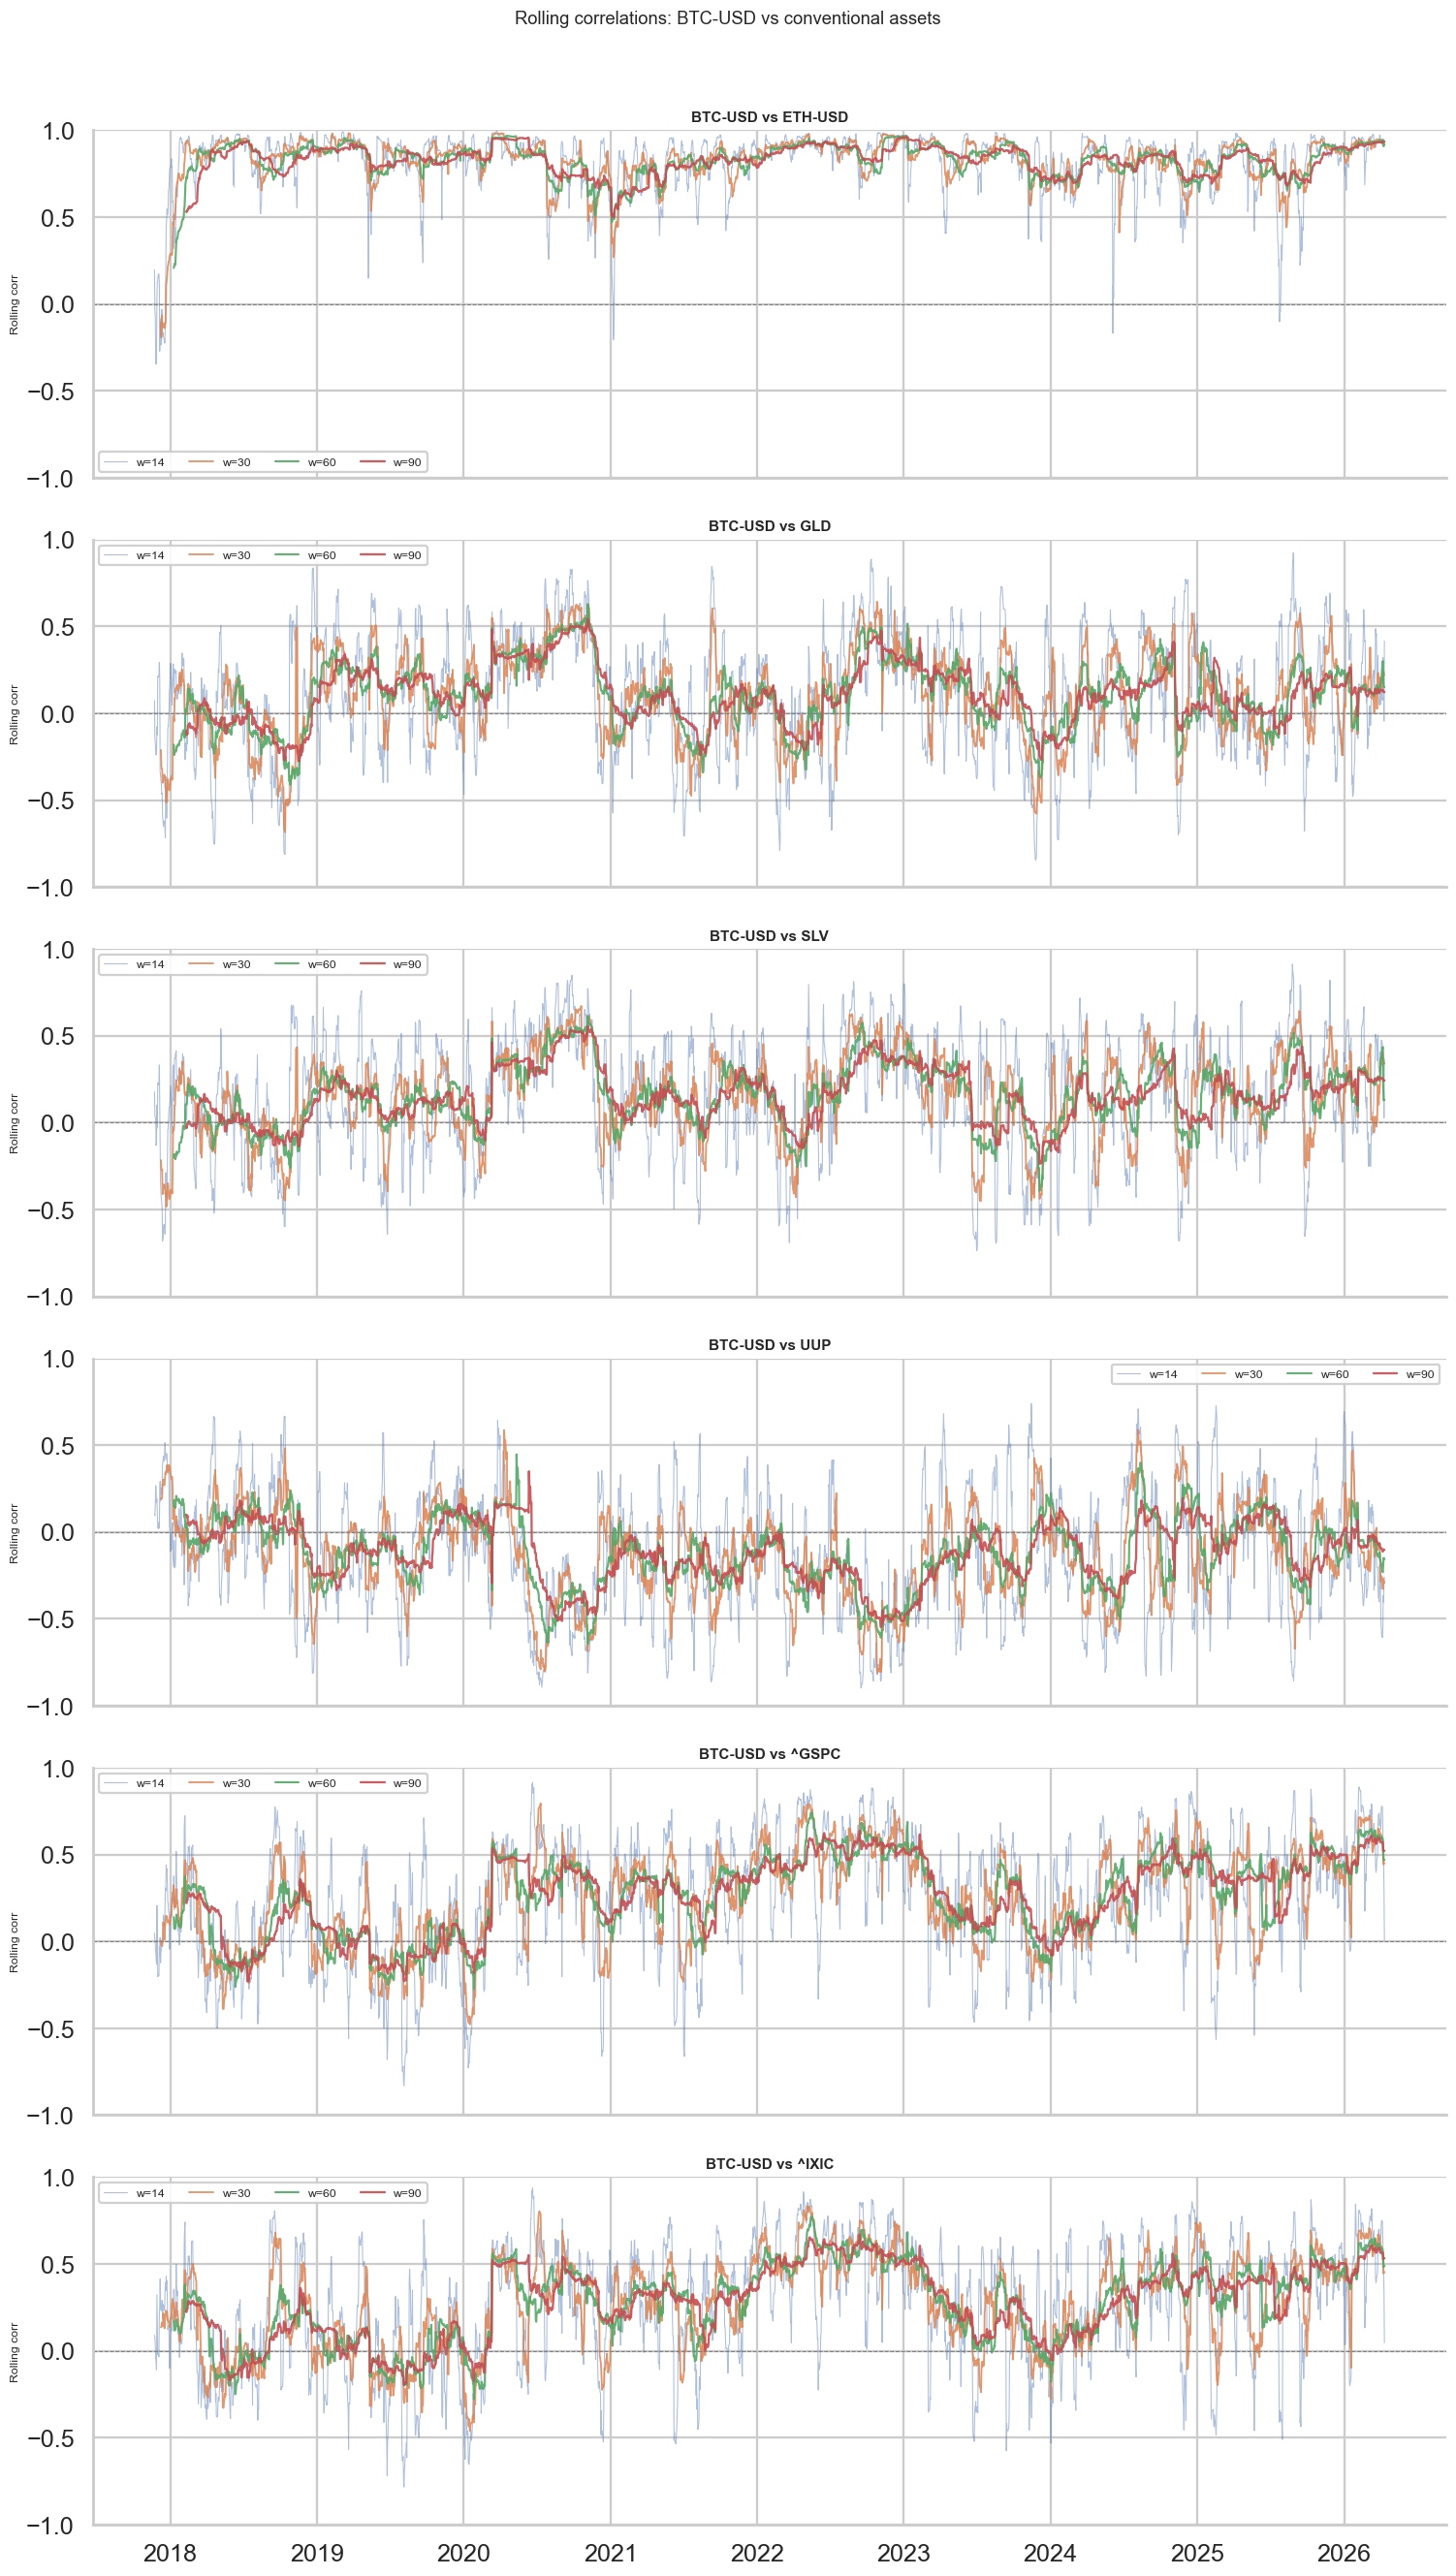

In [8]:
# ─── Rolling correlation: BTC vs all ──────────────────────────────
base = cfg['base_asset']
others = [c for c in rets.columns if c != base]
windows = cfg['rolling_windows']

# Visual weight per window: w=14 is noisiest, give it lighter treatment
_lw_map   = {14: 0.7, 30: 1.2, 60: 1.4, 90: 1.5}
_alpha_map = {14: 0.45, 30: 0.85, 60: 0.9, 90: 0.9}

fig, axes = plt.subplots(len(others), 1, figsize=(14, 4.0 * len(others)), sharex=True)
if len(others) == 1:
    axes = [axes]

for ax, other in zip(axes, others):
    for w in windows:
        rc = rolling_corr(rets[base], rets[other], w).dropna()
        lw    = _lw_map.get(w, 1.0)
        alpha = _alpha_map.get(w, 0.9)
        ax.plot(rc.index, rc, label=f'w={w}', lw=lw, alpha=alpha)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.set_title(f'{base} vs {other}', fontsize=10)
    ax.legend(ncol=4, fontsize=8)
    ax.set_ylim(-1, 1)
    ax.set_ylabel('Rolling corr', fontsize=8)

plt.suptitle(f'Rolling correlations: {base} vs conventional assets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_rolling_corr_all.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ─── ADF stationarity test on rolling correlations ────────────────
from statsmodels.tsa.stattools import adfuller

rows = []
for other in others:
    for w in windows:
        rc = rolling_corr(rets[base], rets[other], w).dropna()
        adf_stat, adf_p, _, _, _, _ = adfuller(rc, maxlag=10, autolag='AIC')
        rows.append({
            'pair': f'{base} vs {other}',
            'window': w,
            'ADF_stat': round(adf_stat, 3),
            'p_value': round(adf_p, 4),
            'Stationary (5%)': 'Yes' if adf_p < 0.05 else 'No'
        })

adf_df = pd.DataFrame(rows)
print(adf_df.to_string(index=False))

              pair  window  ADF_stat  p_value Stationary (5%)
BTC-USD vs ETH-USD      14   -10.782   0.0000             Yes
BTC-USD vs ETH-USD      30    -7.925   0.0000             Yes
BTC-USD vs ETH-USD      60    -5.874   0.0000             Yes
BTC-USD vs ETH-USD      90    -4.396   0.0003             Yes
    BTC-USD vs GLD      14   -11.303   0.0000             Yes
    BTC-USD vs GLD      30    -6.708   0.0000             Yes
    BTC-USD vs GLD      60    -4.858   0.0000             Yes
    BTC-USD vs GLD      90    -3.570   0.0064             Yes
    BTC-USD vs SLV      14   -11.380   0.0000             Yes
    BTC-USD vs SLV      30    -7.098   0.0000             Yes
    BTC-USD vs SLV      60    -4.750   0.0001             Yes
    BTC-USD vs SLV      90    -3.757   0.0034             Yes
    BTC-USD vs UUP      14   -11.412   0.0000             Yes
    BTC-USD vs UUP      30    -6.662   0.0000             Yes
    BTC-USD vs UUP      60    -4.590   0.0001             Yes
    BTC-

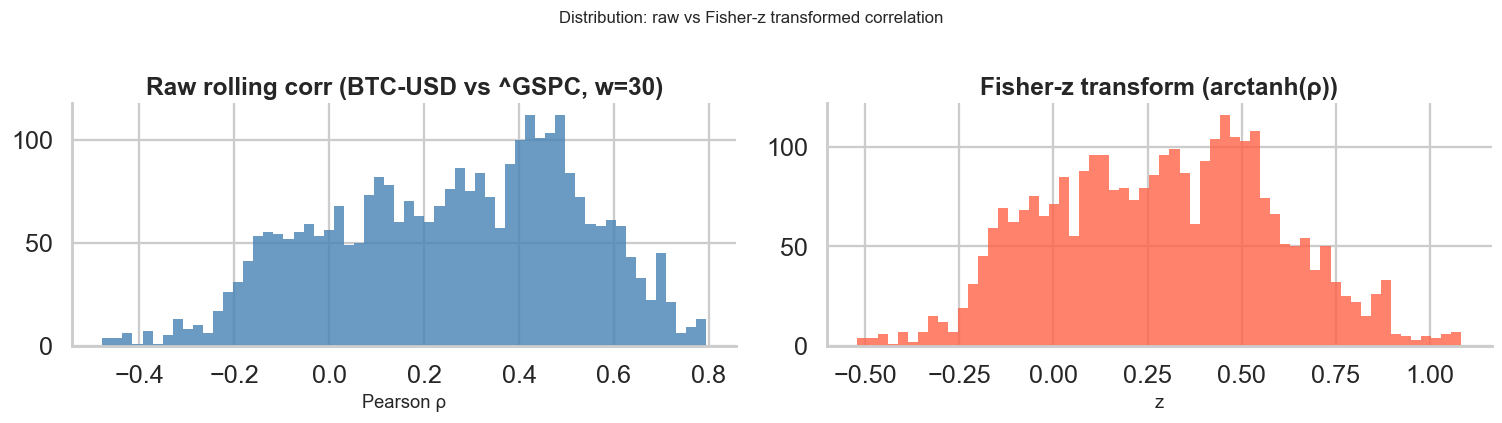

Shapiro-Wilk p-value  |  raw corr: 0.0000  |  Fisher-z: 0.0000
(Higher p → more Gaussian → Fisher-z is preferred for ML)


In [10]:
# ─── Fisher-z transform illustration ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
other = '^GSPC'
w = 30
rc = rolling_corr(rets[base], rets[other], w).dropna()
fz = fisher_z(rc)

axes[0].hist(rc.dropna(), bins=60, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_title(f'Raw rolling corr ({base} vs {other}, w={w})')
axes[0].set_xlabel('Pearson ρ')

axes[1].hist(fz.dropna(), bins=60, color='tomato', alpha=0.8, edgecolor='none')
axes[1].set_title(f'Fisher-z transform (arctanh(ρ))')
axes[1].set_xlabel('z')

plt.suptitle('Distribution: raw vs Fisher-z transformed correlation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_fisher_transform.png'), dpi=130)
plt.show()

# Normality tests
_, p_raw = stats.shapiro(rc.dropna().sample(min(5000, len(rc)), random_state=42))
_, p_fz  = stats.shapiro(fz.dropna().sample(min(5000, len(fz)), random_state=42))
print(f'Shapiro-Wilk p-value  |  raw corr: {p_raw:.4f}  |  Fisher-z: {p_fz:.4f}')
print('(Higher p → more Gaussian → Fisher-z is preferred for ML)')

In [11]:
print('✅ EDA complete. All figures saved to:', paths.figures)

✅ EDA complete. All figures saved to: D:/clode9\outputs\figures
